In [1]:
import pandas as pd
from pathlib import Path

In [2]:
data_path = Path("../data/raw/job_bank_jan_2025.csv")

print(data_path.resolve())
print(data_path.exists())

C:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\data\raw\job_bank_jan_2025.csv
True


In [3]:
job_postings = pd.read_csv(
    data_path,
    sep="\t",
    encoding="utf-16",
    na_values="NA",
    low_memory=False
)

job_postings.shape

(101570, 64)

In [4]:
job_postings.head()


,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Condition Vision Care,Salary Condition Other Benefits,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time
0,14108325,retail sales representative,Remote Sales Representative (No Cold Calling),6421.0,Retail salespersons,64100.0,Retail salespersons and visual merchandisers,1,2025/01/10,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
1,14131905,business development officer,Business Development Representative,4163.0,Business development officers and marketing re...,41402.0,Business development officers and market resea...,1,2025/01/15,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
2,14170021,financial accountant,NaN,1111.0,Financial auditors and accountants,11100.0,Financial auditors and accountants,1,2025/01/29,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
3,14122545,Christmas tree shearer,NaN,8432.0,Nursery and greenhouse workers,85103.0,Nursery and greenhouse labourers,0,2025/01/16,30,...,No,No,NaN,NaN,Week,40.0,60.0,No,NaN,NaN
4,14072526,administrative coordinator,(PTL Canada) Operations Coordinator,1221.0,Administrative officers,13100.0,Administrative officers,1,2025/01/01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN


In [5]:
job_postings.columns.tolist()

['WIC Job Location Snapshot ID',
 'Job Title',
 'Original Job Title',
 'NOC 2016 Code',
 'NOC 2016 Code Name',
 'NOC21 Code',
 'NOC21 Code Name',
 'External Indicator',
 'First Posting Date',
 'Vacancy Count',
 'Education LOS',
 'Experience Level',
 'Government Type',
 'Placement Agency',
 'NAICS',
 'Province/Territory',
 'City',
 'Work Location Postal Code',
 'Economic  Region',
 'Various Location',
 'Employment Type',
 'Employment Term',
 'Employment Term Start Date',
 'Employment Term End Date',
 'Employment Term Oncall',
 'Employment Term Overtime',
 'Employment Term Day',
 'Employment Term Evening',
 'Employment Term Shift',
 'Employment Term Weekend',
 'Employment Term Night',
 'Employment Term Telework',
 'Employment Term Early',
 'Employment Term Flex',
 'Employment Term Morning',
 'Employment Term TBD',
 'Salary Condition Detail',
 'Salary Per',
 'Salary Minimum',
 'Salary Maximum',
 'Salary Condition Collective',
 'Salary Condition Bonus',
 'Salary Condition Disability',
 'Sa

In [6]:
job_postings.info()

<class 'pandas.DataFrame'>
RangeIndex: 101570 entries, 0 to 101569
Data columns (total 64 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   WIC Job Location Snapshot ID      101570 non-null  int64  
 1   Job Title                         101570 non-null  str    
 2   Original Job Title                57681 non-null   str    
 3   NOC 2016 Code                     101135 non-null  float64
 4   NOC 2016 Code Name                101135 non-null  str    
 5   NOC21 Code                        101144 non-null  float64
 6   NOC21 Code Name                   101144 non-null  str    
 7   External Indicator                101570 non-null  int64  
 8   First Posting Date                101570 non-null  str    
 9   Vacancy Count                     101570 non-null  int64  
 10  Education LOS                     25789 non-null   str    
 11  Experience Level                  25789 non-null   str    
 12 

In [7]:
missing_percentage = (
    job_postings.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percentage.head(15)

Commission Type               99.844442
Commission PER                99.844442
Employment Term End Date      99.678055
Work Hours From Time          99.296052
Work Hours To Time            99.296052
Employment Term Start Date    94.960126
Government Type               74.876440
Education LOS                 74.609629
Employment Term Oncall        74.609629
Employment Term Overtime      74.609629
Employment Term Day           74.609629
Employment Term Evening       74.609629
NAICS                         74.609629
Employment Term Weekend       74.609629
Experience Level              74.609629
dtype: float64

In [8]:
job_postings.duplicated().sum()

np.int64(0)

In [9]:
quality_summary = pd.DataFrame({
    "data_type": job_postings.dtypes.astype(str),
    "missing_count": job_postings.isna().sum(),
    "missing_percentage": job_postings.isna().mean().mul(100).round(2),
    "unique_values": job_postings.nunique(dropna=True)
})

quality_summary.sort_values(
    "missing_percentage",
    ascending=False
).head(20)

,data_type,missing_count,missing_percentage,unique_values
Commission Type,str,101412,99.84,2
Commission PER,str,101412,99.84,4
Employment Term End Date,str,101243,99.68,179
Work Hours From Time,str,100855,99.30,39
Work Hours To Time,str,100855,99.30,40
Employment Term Start Date,str,96451,94.96,205
Government Type,str,76052,74.88,4
Education LOS,str,75781,74.61,11
Employment Term Oncall,str,75781,74.61,2
Employment Term Overtime,str,75781,74.61,2


In [10]:
keywords = [
    "title", "location", "province", "city", "noc",
    "salary", "wage", "vacan", "education", "experience"
]

key_columns = [
    column for column in job_postings.columns
    if any(keyword in column.lower() for keyword in keywords)
]

key_columns

['WIC Job Location Snapshot ID',
 'Job Title',
 'Original Job Title',
 'NOC 2016 Code',
 'NOC 2016 Code Name',
 'NOC21 Code',
 'NOC21 Code Name',
 'Vacancy Count',
 'Education LOS',
 'Experience Level',
 'Province/Territory',
 'City',
 'Work Location Postal Code',
 'Various Location',
 'Salary Condition Detail',
 'Salary Per',
 'Salary Minimum',
 'Salary Maximum',
 'Salary Condition Collective',
 'Salary Condition Bonus',
 'Salary Condition Disability',
 'Salary Condition Gratuity',
 'Salary Condition Medical',
 'Salary Condition Mileage',
 'Salary Condition Piecework',
 'Salary Condition Commission',
 'Salary Condition RESP',
 'Salary Condition Dental',
 'Salary Condition Group Insurance',
 'Salary Condition Life Insurance',
 'Salary Condition Pension',
 'Salary Condition RRSP',
 'Salary Condition Other Benefits']

## Initial Data-Quality Findings

Several optional fields, including commission details and exact working times, have more than 99% missing data. Education, experience, and some employment-condition fields are available for only a subset of postings. These columns will be evaluated against the project’s business questions before deciding whether to retain, transform, or remove them.

## Data Cleaning

A separate working copy is created so the original imported dataset remains unchanged.

In [11]:
job_postings_clean = job_postings.copy()

In [12]:
job_postings_clean.columns = (
    job_postings_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

job_postings_clean.columns.tolist()

['wic_job_location_snapshot_id',
 'job_title',
 'original_job_title',
 'noc_2016_code',
 'noc_2016_code_name',
 'noc21_code',
 'noc21_code_name',
 'external_indicator',
 'first_posting_date',
 'vacancy_count',
 'education_los',
 'experience_level',
 'government_type',
 'placement_agency',
 'naics',
 'province_territory',
 'city',
 'work_location_postal_code',
 'economic_region',
 'various_location',
 'employment_type',
 'employment_term',
 'employment_term_start_date',
 'employment_term_end_date',
 'employment_term_oncall',
 'employment_term_overtime',
 'employment_term_day',
 'employment_term_evening',
 'employment_term_shift',
 'employment_term_weekend',
 'employment_term_night',
 'employment_term_telework',
 'employment_term_early',
 'employment_term_flex',
 'employment_term_morning',
 'employment_term_tbd',
 'salary_condition_detail',
 'salary_per',
 'salary_minimum',
 'salary_maximum',
 'salary_condition_collective',
 'salary_condition_bonus',
 'salary_condition_disability',
 'sal

In [13]:
job_postings_clean.columns.duplicated().sum()

np.int64(0)

In [14]:
keywords = [
    "title", "province", "city", "location", "noc",
    "salary", "wage", "vacan", "education",
    "experience", "date"
]

business_columns = [
    column for column in job_postings_clean.columns
    if any(keyword in column for keyword in keywords)
]

business_columns

['wic_job_location_snapshot_id',
 'job_title',
 'original_job_title',
 'noc_2016_code',
 'noc_2016_code_name',
 'noc21_code',
 'noc21_code_name',
 'first_posting_date',
 'vacancy_count',
 'education_los',
 'experience_level',
 'province_territory',
 'city',
 'work_location_postal_code',
 'various_location',
 'employment_term_start_date',
 'employment_term_end_date',
 'salary_condition_detail',
 'salary_per',
 'salary_minimum',
 'salary_maximum',
 'salary_condition_collective',
 'salary_condition_bonus',
 'salary_condition_disability',
 'salary_condition_gratuity',
 'salary_condition_medical',
 'salary_condition_mileage',
 'salary_condition_piecework',
 'salary_condition_commission',
 'salary_condition_resp',
 'salary_condition_dental',
 'salary_condition_group_insurance',
 'salary_condition_life_insurance',
 'salary_condition_pension',
 'salary_condition_rrsp',
 'salary_condition_other_benefits']

In [15]:
job_postings_clean[business_columns].head()

,wic_job_location_snapshot_id,job_title,original_job_title,noc_2016_code,noc_2016_code_name,noc21_code,noc21_code_name,first_posting_date,vacancy_count,education_los,...,salary_condition_mileage,salary_condition_piecework,salary_condition_commission,salary_condition_resp,salary_condition_dental,salary_condition_group_insurance,salary_condition_life_insurance,salary_condition_pension,salary_condition_rrsp,salary_condition_other_benefits
0,14108325,retail sales representative,Remote Sales Representative (No Cold Calling),6421.0,Retail salespersons,64100.0,Retail salespersons and visual merchandisers,2025/01/10,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14131905,business development officer,Business Development Representative,4163.0,Business development officers and marketing re...,41402.0,Business development officers and market resea...,2025/01/15,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14170021,financial accountant,NaN,1111.0,Financial auditors and accountants,11100.0,Financial auditors and accountants,2025/01/29,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14122545,Christmas tree shearer,NaN,8432.0,Nursery and greenhouse workers,85103.0,Nursery and greenhouse labourers,2025/01/16,30,"No degree, certificate or diploma",...,No,No,No,No,No,No,No,No,No,No
4,14072526,administrative coordinator,(PTL Canada) Operations Coordinator,1221.0,Administrative officers,13100.0,Administrative officers,2025/01/01,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
column_groups = {
    "salary": [
        column for column in job_postings_clean.columns
        if any(word in column for word in ["salary", "wage", "pay"])
    ],
    "location": [
        column for column in job_postings_clean.columns
        if any(word in column for word in ["province", "city", "location"])
    ],
    "occupation": [
        column for column in job_postings_clean.columns
        if any(word in column for word in ["job_title", "noc"])
    ],
    "dates": [
        column for column in job_postings_clean.columns
        if "date" in column
    ]
}

for group, columns in column_groups.items():
    print(f"\n{group.upper()}:")
    print(columns)


SALARY:
['salary_condition_detail', 'salary_per', 'salary_minimum', 'salary_maximum', 'salary_condition_collective', 'salary_condition_bonus', 'salary_condition_disability', 'salary_condition_gratuity', 'salary_condition_medical', 'salary_condition_mileage', 'salary_condition_piecework', 'salary_condition_commission', 'salary_condition_resp', 'salary_condition_dental', 'salary_condition_group_insurance', 'salary_condition_life_insurance', 'salary_condition_pension', 'salary_condition_rrsp', 'salary_condition_other_benefits']

LOCATION:
['wic_job_location_snapshot_id', 'province_territory', 'city', 'work_location_postal_code', 'various_location']

OCCUPATION:
['job_title', 'original_job_title', 'noc_2016_code', 'noc_2016_code_name', 'noc21_code', 'noc21_code_name']

DATES:
['first_posting_date', 'employment_term_start_date', 'employment_term_end_date']


In [17]:
date_columns = column_groups["dates"]

for column in date_columns:
    job_postings_clean[column] = pd.to_datetime(
        job_postings_clean[column],
        errors="coerce"
    )

job_postings_clean[date_columns].dtypes

first_posting_date            datetime64[us]
employment_term_start_date    datetime64[us]
employment_term_end_date      datetime64[us]
dtype: object

In [18]:
id_columns = [
    column for column in job_postings_clean.columns
    if column.endswith("_id") or "snapshot_id" in column
]

id_columns

['wic_job_location_snapshot_id']

In [19]:
for column in id_columns:
    print(
        column,
        "- missing:", job_postings_clean[column].isna().sum(),
        "- duplicated:", job_postings_clean[column].duplicated().sum()
    )

wic_job_location_snapshot_id - missing: 0 - duplicated: 0


In [20]:
job_postings_clean.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
wic_job_location_snapshot_id,101570.0,1.413233e+07,34517.021035,14071180.0,14102154.25,14132621.5,14162572.75,14208864.0
noc_2016_code,101135.0,4.469752e+03,2571.889755,11.0,2132.00,5241.0,6552.00,9619.0
noc21_code,101144.0,4.753657e+04,23714.711599,10.0,22114.00,62010.0,65102.00,95109.0
external_indicator,101570.0,7.460963e-01,0.435245,0.0,0.00,1.0,1.00,1.0
vacancy_count,101570.0,1.375377e+00,2.486833,1.0,1.00,1.0,1.00,150.0
salary_minimum,53663.0,1.250223e+04,241850.502272,0.0,19.52,26.0,37.50,55547442.0
salary_maximum,53663.0,1.520222e+04,243158.686662,0.0,20.75,28.5,42.00,55547442.0
hours_minimum,28969.0,3.817846e+01,71.206125,1.0,30.00,35.0,40.00,2184.0
hours_maximum,28969.0,4.227726e+01,76.758826,1.0,35.00,40.0,40.00,3000.0


## Salary Data Inspection

Salary values must be interpreted using their stated payment period before postings can be compared. This section evaluates salary coverage, units, and potentially invalid values.

In [21]:
job_postings_clean["salary_per"].value_counts(dropna=False)

salary_per
NaN          47907
Hour         43964
Year          8152
Week           557
Bi-weekly      463
Month          390
Day            137
Name: count, dtype: int64

In [22]:
salary_columns = [
    "salary_per",
    "salary_minimum",
    "salary_maximum"
]

job_postings_clean[salary_columns].isna().sum()

salary_per        47907
salary_minimum    47907
salary_maximum    47907
dtype: int64

In [23]:
salary_by_period = (
    job_postings_clean
    .groupby("salary_per", dropna=False)
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        median_minimum=("salary_minimum", "median"),
        median_maximum=("salary_maximum", "median"),
        lowest_minimum=("salary_minimum", "min"),
        highest_maximum=("salary_maximum", "max")
    )
    .sort_values("posting_count", ascending=False)
)

salary_by_period

,posting_count,median_minimum,median_maximum,lowest_minimum,highest_maximum
salary_per,,,,,
NaN,47907,2.777464e+07,27774636.5,1831.00,55547442.0
Hour,43964,2.317000e+01,25.0,0.00,182808.0
Year,8152,6.136729e+04,75000.0,0.00,1360000.0
Week,557,6.300000e+02,700.0,0.01,80000.0
Bi-weekly,463,1.501110e+03,1700.0,0.01,78600.0
Month,390,4.317000e+03,5000.0,34.07,120000.0
Day,137,2.100000e+02,264.0,16.00,5000.0


In [24]:
salary_quality_checks = pd.Series({
    "missing_both_salary_values": (
        job_postings_clean["salary_minimum"].isna()
        & job_postings_clean["salary_maximum"].isna()
    ).sum(),

    "minimum_greater_than_maximum": (
        job_postings_clean["salary_minimum"]
        > job_postings_clean["salary_maximum"]
    ).sum(),

    "minimum_at_or_below_zero": (
        job_postings_clean["salary_minimum"] <= 0
    ).sum(),

    "maximum_at_or_below_zero": (
        job_postings_clean["salary_maximum"] <= 0
    ).sum()
})

salary_quality_checks

missing_both_salary_values      47907
minimum_greater_than_maximum        0
minimum_at_or_below_zero           15
maximum_at_or_below_zero            2
dtype: int64

In [25]:
salary_missing_pattern = pd.crosstab(
    job_postings_clean["salary_per"].isna(),
    job_postings_clean["salary_minimum"].isna(),
    rownames=["salary_period_missing"],
    colnames=["salary_minimum_missing"]
)

salary_missing_pattern

salary_minimum_missing,False,True
salary_period_missing,,
False,53661,2
True,2,47905


In [26]:
missing_period_with_salary = job_postings_clean[
    job_postings_clean["salary_per"].isna()
    & job_postings_clean["salary_minimum"].notna()
]

missing_period_with_salary[
    ["job_title", "salary_per", "salary_minimum", "salary_maximum"]
].head(10)

,job_title,salary_per,salary_minimum,salary_maximum
19550,wills and estates paralegal,NaN,55547442.0,55547442.0
32095,licensed practical nurse (L.P.N.),NaN,1831.0,1831.0


### Salary Normalization Assumptions

To compare postings consistently, salaries are converted to estimated hourly values using a standard 40-hour workweek and 52 working weeks per year:

- Hour: 1 1 hour
- Day: 8 hours
- Week: 40 hours
- Bi-weekly: 80 hours
- Month: 2,080 ÷ 12 hours
- Year: 2,080 hours

Postings without a stated salary period or with invalid salary ranges are not assigned an hourly salary.

In [27]:
hours_per_period = {
    "Hour": 1,
    "Day": 8,
    "Week": 40,
    "Bi-weekly": 80,
    "Month": 2080 / 12,
    "Year": 2080
}

conversion_hours = job_postings_clean["salary_per"].map(hours_per_period)

valid_salary = (
    conversion_hours.notna()
    & job_postings_clean["salary_minimum"].gt(0)
    & job_postings_clean["salary_maximum"].gt(0)
    & job_postings_clean["salary_minimum"].le(
        job_postings_clean["salary_maximum"]
    )
)

job_postings_clean["hourly_salary_minimum"] = (
    job_postings_clean["salary_minimum"] / conversion_hours
).where(valid_salary)

job_postings_clean["hourly_salary_maximum"] = (
    job_postings_clean["salary_maximum"] / conversion_hours
).where(valid_salary)

job_postings_clean["hourly_salary_midpoint"] = (
    job_postings_clean["hourly_salary_minimum"]
    + job_postings_clean["hourly_salary_maximum"]
) / 2

In [28]:
job_postings_clean[
    [
        "hourly_salary_minimum",
        "hourly_salary_maximum",
        "hourly_salary_midpoint"
    ]
].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T.round(2)

,count,mean,std,min,1%,5%,50%,95%,99%,max
hourly_salary_minimum,53646.0,362.56,5049.67,0.0,12.60,16.00,24.04,50.00,100.0,140621.0
hourly_salary_maximum,53646.0,431.67,6069.55,0.0,14.42,16.50,27.00,57.69,140.0,182808.0
hourly_salary_midpoint,53646.0,397.11,5549.25,0.0,14.42,16.35,25.50,52.88,115.0,161714.5


In [29]:
job_postings_clean.nlargest(
    10,
    "hourly_salary_midpoint"
)[
    [
        "job_title",
        "province_territory",
        "salary_per",
        "salary_minimum",
        "salary_maximum",
        "hourly_salary_midpoint"
    ]
]

,job_title,province_territory,salary_per,salary_minimum,salary_maximum,hourly_salary_midpoint
40578,social service general manager,Québec,Hour,140621.0,182808.0,161714.5
78858,social service general manager,Québec,Hour,140621.0,182808.0,161714.5
19504,senior accountant,Saskatchewan,Hour,120000.0,150000.0,135000.0
40549,"assistant executive director - health, educati...",Québec,Hour,114969.0,149460.0,132214.5
11219,computer programs manager,Manitoba,Hour,106000.0,119240.0,112620.0
18096,computer programs manager,Newfoundland and Labrador,Hour,106000.0,119240.0,112620.0
18654,computer programs manager,Ontario,Hour,106000.0,119240.0,112620.0
24234,computer programs manager,Ontario,Hour,106000.0,119240.0,112620.0
30529,computer programs manager,New Brunswick,Hour,106000.0,119240.0,112620.0
48677,computer programs manager,British Columbia,Hour,106000.0,119240.0,112620.0


### Salary Plausibility Rules

Several postings contain annual-style salary amounts while being labelled as hourly. Because the intended period cannot be verified, these values are not automatically corrected.

For salary analysis, hourly ranges must:

- Have a known payment period
- Have a minimum salary of at least $10 per hour
- Have a maximum salary no greater than $500 per hour
- Have a minimum that does not exceed the maximum

The original salary fields remain unchanged for traceability.

In [30]:
HOURLY_LOWER_BOUND = 10
HOURLY_UPPER_BOUND = 500

job_postings_clean["salary_valid_for_analysis"] = (
    job_postings_clean["hourly_salary_minimum"].ge(HOURLY_LOWER_BOUND)
    & job_postings_clean["hourly_salary_maximum"].le(HOURLY_UPPER_BOUND)
    & job_postings_clean["hourly_salary_minimum"].le(
        job_postings_clean["hourly_salary_maximum"]
    )
)

In [31]:
salary_filter_summary = pd.Series({
    "total_postings": len(job_postings_clean),

    "converted_salary_postings": (
        job_postings_clean["hourly_salary_midpoint"].notna().sum()
    ),

    "below_lower_bound": (
        job_postings_clean["hourly_salary_minimum"]
        < HOURLY_LOWER_BOUND
    ).sum(),

    "above_upper_bound": (
        job_postings_clean["hourly_salary_maximum"]
        > HOURLY_UPPER_BOUND
    ).sum(),

    "valid_salary_postings": (
        job_postings_clean["salary_valid_for_analysis"].sum()
    )
})

salary_filter_summary

total_postings               101570
converted_salary_postings     53646
below_lower_bound               473
above_upper_bound               277
valid_salary_postings         52896
dtype: int64

In [32]:
analysis_data = job_postings_clean.copy()

hourly_salary_columns = [
    "hourly_salary_minimum",
    "hourly_salary_maximum",
    "hourly_salary_midpoint"
]

analysis_data.loc[
    ~analysis_data["salary_valid_for_analysis"],
    hourly_salary_columns
] = float("nan")

In [33]:
analysis_data[hourly_salary_columns].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T.round(2)

,count,mean,std,min,1%,5%,50%,95%,99%,max
hourly_salary_minimum,52896.0,27.49,13.66,10.0,15.00,16.00,24.04,48.08,76.92,437.5
hourly_salary_maximum,52896.0,30.77,18.03,10.0,15.25,17.00,27.00,56.73,99.05,437.5
hourly_salary_midpoint,52896.0,29.13,15.42,10.0,15.25,16.75,25.53,51.75,88.00,437.5


In [34]:
province_summary = (
    analysis_data
    .groupby("province_territory", dropna=False)
    .agg(
        posting_count=("wic_job_location_snapshot_id", "count"),
        total_vacancies=("vacancy_count", "sum"),
        valid_salary_postings=("salary_valid_for_analysis", "sum"),
        median_hourly_salary=("hourly_salary_midpoint", "median")
    )
    .sort_values("posting_count", ascending=False)
)

province_summary["salary_coverage_percentage"] = (
    province_summary["valid_salary_postings"]
    / province_summary["posting_count"]
    * 100
).round(1)

province_summary

,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,salary_coverage_percentage
province_territory,,,,,
Ontario,34638,44421,16574,26.500000,47.8
Québec,20410,27266,7789,25.000000,38.2
British Columbia,17648,26929,12100,28.000000,68.6
Alberta,12591,18198,7486,25.000000,59.5
Saskatchewan,5759,6836,3661,24.005000,63.6
Nova Scotia,3244,4627,1436,22.301063,44.3
Manitoba,2544,3934,1398,24.000000,55.0
New Brunswick,2072,3208,914,20.500000,44.1
Newfoundland and Labrador,1589,2537,834,20.840000,52.5


In [35]:
province_summary["posting_share_percentage"] = (
    province_summary["posting_count"]
    / province_summary["posting_count"].sum()
    * 100
).round(1)

province_summary["vacancies_per_posting"] = (
    province_summary["total_vacancies"]
    / province_summary["posting_count"]
).round(2)

province_summary.round({
    "median_hourly_salary": 2,
    "salary_coverage_percentage": 1
})

,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,salary_coverage_percentage,posting_share_percentage,vacancies_per_posting
province_territory,,,,,,,
Ontario,34638,44421,16574,26.50,47.8,34.1,1.28
Québec,20410,27266,7789,25.00,38.2,20.1,1.34
British Columbia,17648,26929,12100,28.00,68.6,17.4,1.53
Alberta,12591,18198,7486,25.00,59.5,12.4,1.45
Saskatchewan,5759,6836,3661,24.01,63.6,5.7,1.19
Nova Scotia,3244,4627,1436,22.30,44.3,3.2,1.43
Manitoba,2544,3934,1398,24.00,55.0,2.5,1.55
New Brunswick,2072,3208,914,20.50,44.1,2.0,1.55
Newfoundland and Labrador,1589,2537,834,20.84,52.5,1.6,1.60


In [36]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

In [38]:
figures_path = Path("../reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

print(figures_path.resolve())

C:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\reports\figures


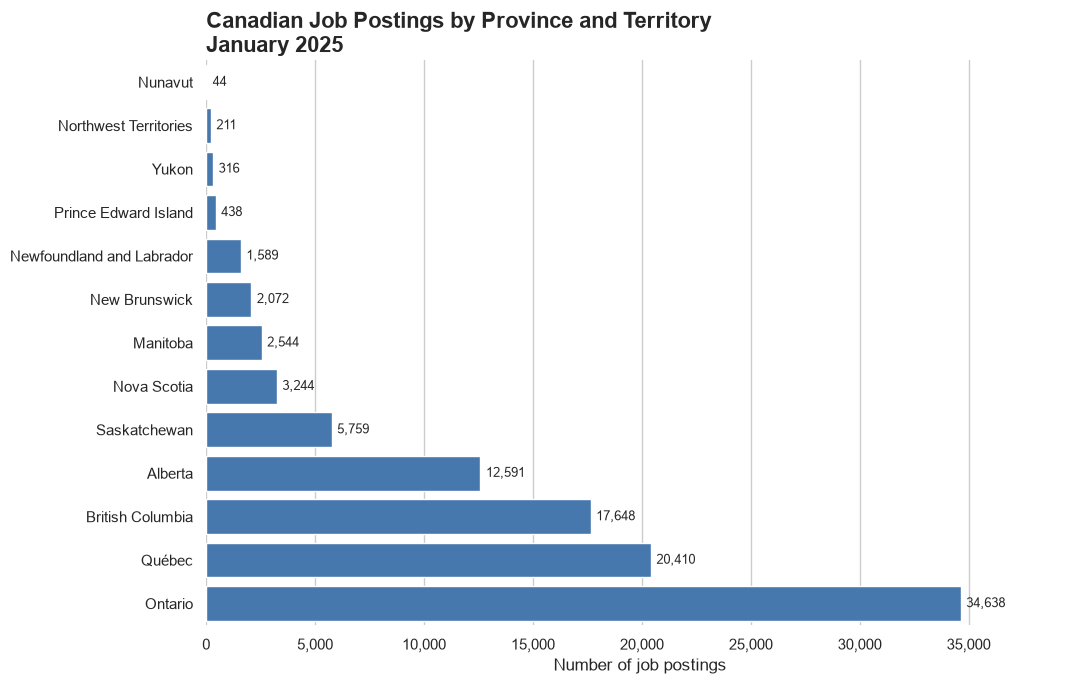

In [39]:
province_chart = (
    province_summary
    .reset_index()
    .dropna(subset=["province_territory"])
    .sort_values("posting_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=province_chart,
    x="posting_count",
    y="province_territory",
    color="#3478C0",
    ax=ax
)

ax.set_title(
    "Canadian Job Postings by Province and Territory\nJanuary 2025",
    loc="left",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of job postings")
ax.set_ylabel("")
ax.set_xlim(0, province_chart["posting_count"].max() * 1.15)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:,.0f}"
        for value in province_chart["posting_count"]
    ],
    padding=4,
    fontsize=9
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(
    figures_path / "job_postings_by_province.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Provincial Hiring Demand

Ontario accounted for the largest number of advertised postings and vacancies in January 2025, followed by Québec, British Columbia, and Alberta. Together, these four provinces dominate the observed hiring market. However, posting volume should not be interpreted as the number of unique jobs because one posting may advertise multiple vacancies.

Salary comparisons require additional caution because salary-reporting coverage differs substantially by province. Results for the territories are based on much smaller samples and should not be compared directly with the largest provincial markets.

In [40]:
%pip install pyarrow


Note: you may need to restart the kernel to use updated packages.


In [41]:
processed_path = Path(
    "../data/processed/job_bank_jan_2025_clean.parquet"
)

analysis_data.to_parquet(
    processed_path,
    index=False
)

print(processed_path.resolve())
print(processed_path.exists())
print(f"File size: {processed_path.stat().st_size / 1_000_000:.1f} MB")

C:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\data\processed\job_bank_jan_2025_clean.parquet
True
File size: 4.2 MB


In [42]:
verification_data = pd.read_parquet(processed_path)

print("Original shape:", analysis_data.shape)
print("Saved shape:", verification_data.shape)

Original shape: (101570, 68)
Saved shape: (101570, 68)


## Data-Preparation Summary

The January 2025 Job Bank dataset was successfully loaded, inspected, and prepared for analysis. Column names were standardized, date fields were converted, duplicate records were checked, and advertised salaries were converted into comparable estimated hourly values.

Original salary fields were preserved. Records with missing payment periods, invalid ranges, or implausible normalized values were excluded only from salary calculations and retained for hiring-demand analysis. The resulting analytical dataset was saved in Parquet format for use in subsequent notebooks.